# Exploratory Analysis

## Goal 

This notebook breaks down the contents of our [disease prediction dataset](https://www.kaggle.com/datasets/kaushil268/disease-prediction-using-machine-learning). There are 132 features, 1 predictor variable, and over 5000 rows, representing individual patients. 

In [47]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

## Exploration of Training Dataset

Gathering some descriptive information on the dataset. As it was obtained from kaggle, a few facts are made available right away: 
1. 42 distinct diseases appear in the 'prognosis' column.
2. Each value for the predictor variables is a 1 (presence of symptom) or 0 (absence of symptom).
3. There are no missing values in the dataset.

In [20]:
train_data = pd.read_csv('data/Training.csv')
train_data.head(10) # looking at the first few rows of data 

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
5,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
6,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
7,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
8,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
9,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [51]:
total_columns = len(train_data.columns)
total_rows = len(train_data['prognosis'])
prognoses = train_data['prognosis'].unique().tolist()

print(f"The training dataset has a total of {total_rows} rows and {total_columns} columns. This means that there are {total_columns - 1} predictor variables. \nwithin the prognosis column, there are {len(prognoses)} diseases included.")

The training dataset has a total of 4920 rows and 134 columns. This means that there are 133 predictor variables. 
within the prognosis column, there are 41 diseases included.


The training dataset has a total of 4920 rows and 134 columns. This means that there are 133 predictor variables. 
within the prognosis column, there are 41 diseases included.

In [8]:
train_data.info() # gathering information related to the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 43.8+ KB


In [25]:
train_data['prognosis'] = train_data['prognosis'].str.title() # Making disease titles look better for plotting. 
prognoses = train_data.columns.difference(['prognosis']).tolist() 
# alright for every disease, you want a plot of all the symptoms presented.
melted_train_data = train_data.melt(id_vars=['prognosis'], value_vars=prognoses).groupby(['prognosis', 'variable']).sum('value')
melted_train_data = melted_train_data[melted_train_data['value'] > 0]


## Visualizing The Dataset

<Axes: title={'center': 'Class Distribution in Dataset'}, xlabel='Prognosis', ylabel='Percentage (%)'>

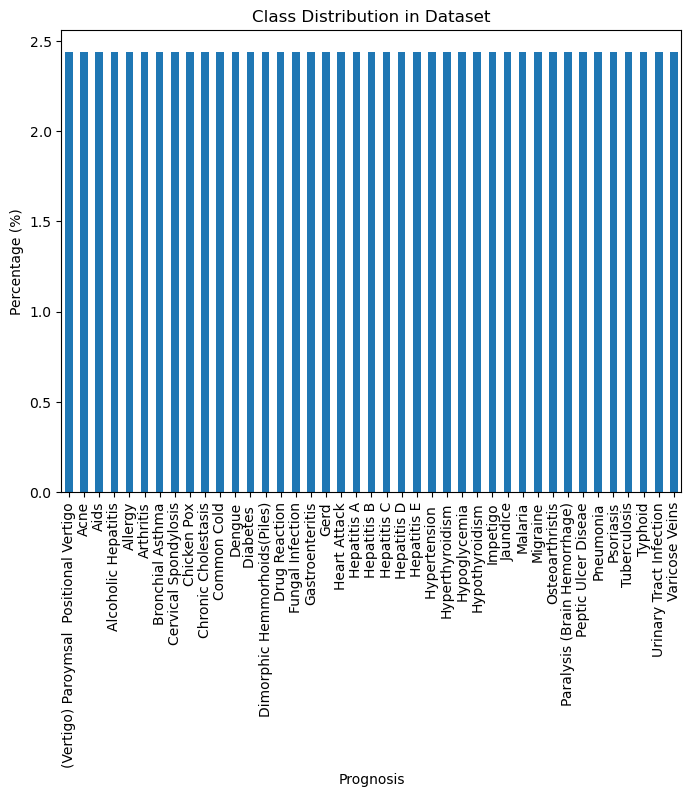

In [31]:
# Looking at the distribution of the prognoses within the dataset - determining if there is an imbalance 
(100 * train_data.groupby('prognosis').size()/train_data.shape[0]).plot(x='prognosis', kind='bar', title='Class Distribution in Dataset', xlabel= "Prognosis", ylabel="Percentage (%)", figsize=(8,6))

In [42]:
value_columns = train_data.columns.difference(['prognosis']).tolist()
melted_train_data = train_data.melt(id_vars=['prognosis'], value_vars=value_columns).groupby(['prognosis', 'variable']).sum('value')
melted_train_data = melted_train_data[melted_train_data['value'] > 0]
melted_train_data

value
prognosis                               variable                      
(Vertigo) Paroymsal  Positional Vertigo headache                 114.0
                                        loss_of_balance          114.0
                                        nausea                   114.0
                                        spinning_movements       108.0
                                        unsteadiness             114.0
...                                                                ...
Varicose Veins                          fatigue                  114.0
                                        obesity                  114.0
                                        prominent_veins_on_calf  114.0
                                        swollen_blood_vessels    108.0
                                        swollen_legs             114.0

[321 rows x 1 columns]

### Distribution of Symptoms per Diagnosis

This step provides an insight on the prevalence of sympoms for each diagnosis within the dataset. The code below counts the occurrences of symptoms observed for each prognosis. The counts are displayed in plots.

In [53]:
prognoses

['Fungal Infection',
 'Allergy',
 'Gerd',
 'Chronic Cholestasis',
 'Drug Reaction',
 'Peptic Ulcer Diseae',
 'Aids',
 'Diabetes ',
 'Gastroenteritis',
 'Bronchial Asthma',
 'Hypertension ',
 'Migraine',
 'Cervical Spondylosis',
 'Paralysis (Brain Hemorrhage)',
 'Jaundice',
 'Malaria',
 'Chicken Pox',
 'Dengue',
 'Typhoid',
 'Hepatitis A',
 'Hepatitis B',
 'Hepatitis C',
 'Hepatitis D',
 'Hepatitis E',
 'Alcoholic Hepatitis',
 'Tuberculosis',
 'Common Cold',
 'Pneumonia',
 'Dimorphic Hemmorhoids(Piles)',
 'Heart Attack',
 'Varicose Veins',
 'Hypothyroidism',
 'Hyperthyroidism',
 'Hypoglycemia',
 'Osteoarthristis',
 'Arthritis',
 '(Vertigo) Paroymsal  Positional Vertigo',
 'Acne',
 'Urinary Tract Infection',
 'Psoriasis',
 'Impetigo']

In [54]:
train_data.melt(id_vars=['prognosis'], value_vars=prognoses).groupby(['prognosis', 'variable']).sum('value')

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['Fungal Infection', 'Allergy', 'Gerd', 'Chronic Cholestasis', 'Drug Reaction', 'Peptic Ulcer Diseae', 'Aids', 'Diabetes ', 'Gastroenteritis', 'Bronchial Asthma', 'Hypertension ', 'Migraine', 'Cervical Spondylosis', 'Paralysis (Brain Hemorrhage)', 'Jaundice', 'Malaria', 'Chicken Pox', 'Dengue', 'Typhoid', 'Hepatitis A', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E', 'Alcoholic Hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia', 'Dimorphic Hemmorhoids(Piles)', 'Heart Attack', 'Varicose Veins', 'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia', 'Osteoarthristis', 'Arthritis', '(Vertigo) Paroymsal  Positional Vertigo', 'Acne', 'Urinary Tract Infection', 'Psoriasis', 'Impetigo']"

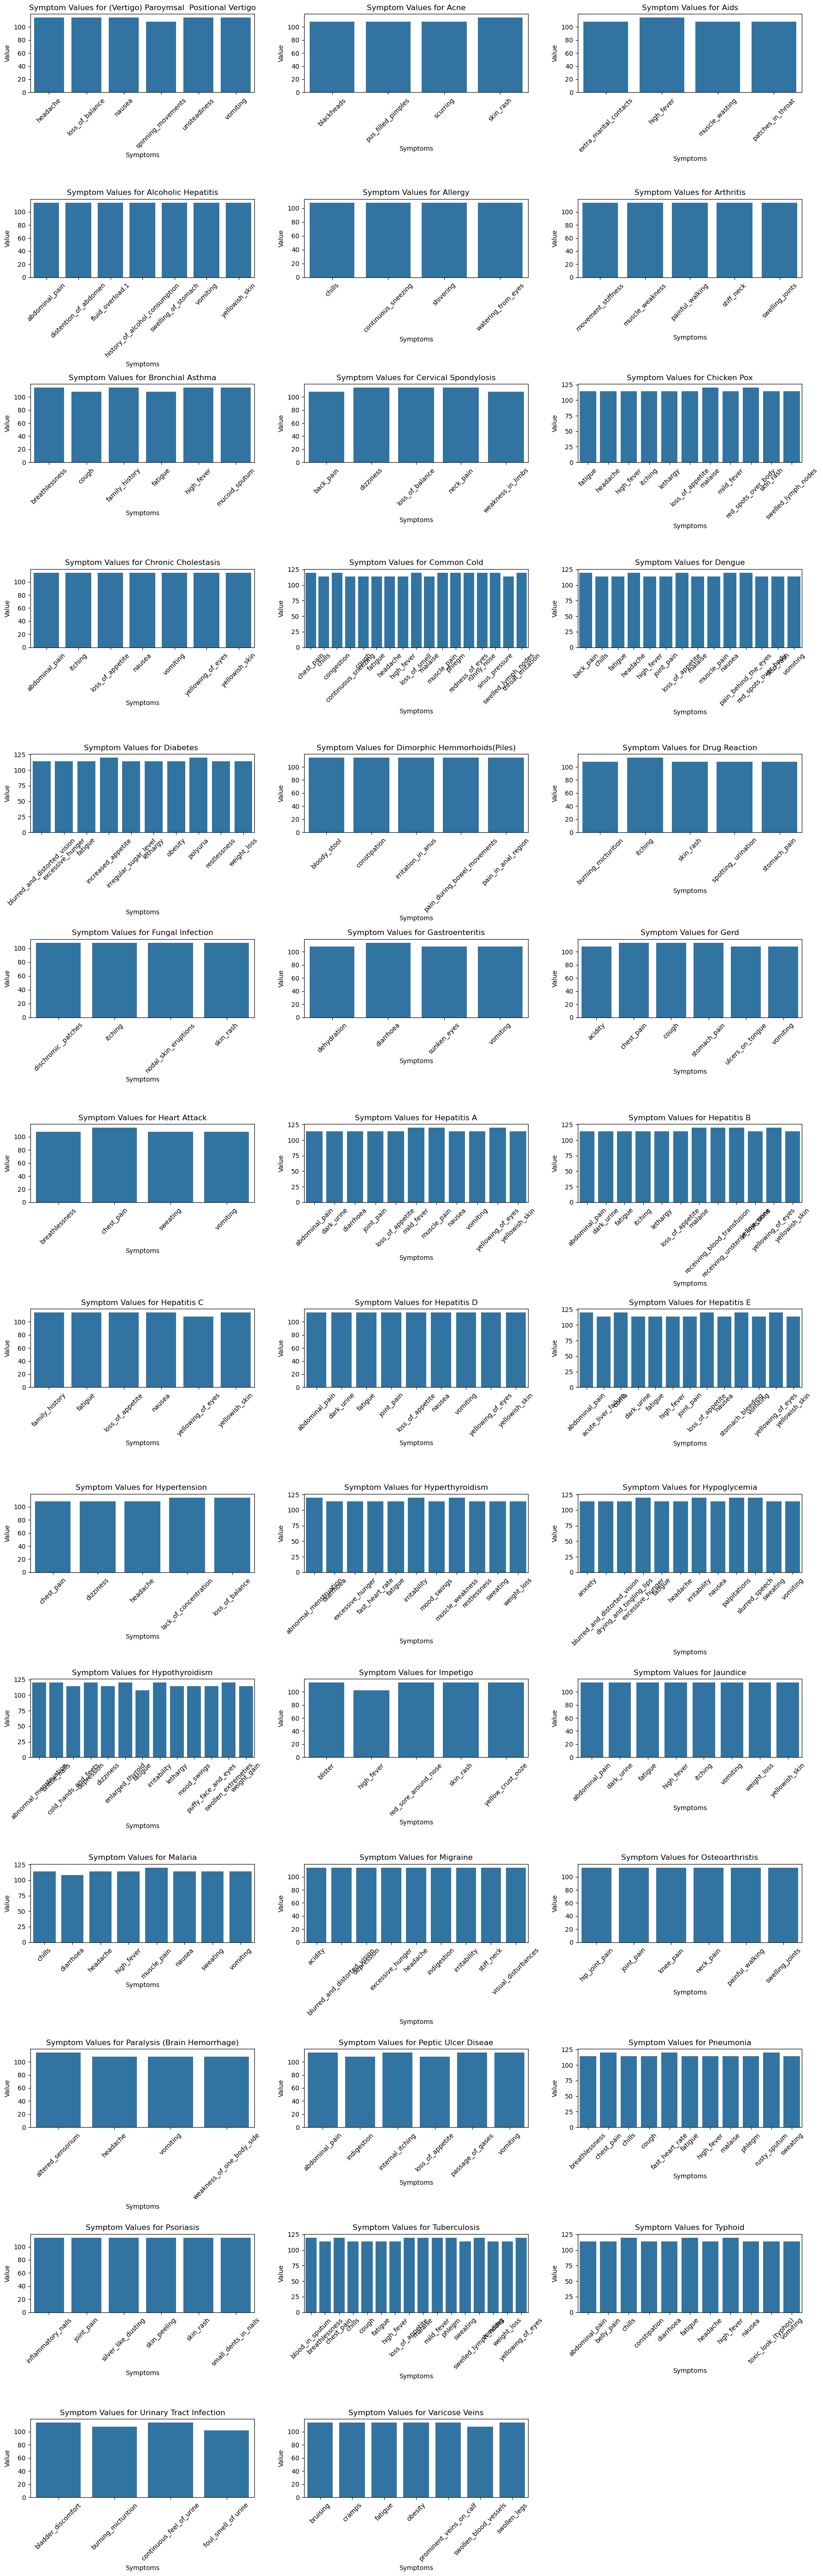

In [34]:
# Determine the number of prognosis categories
prognosis_list = melted_train_data.index.levels[0]
num_prognosis = len(prognosis_list)

# Set up the grid size (for example, 2 columns)
num_cols = 3
num_rows = (num_prognosis + num_cols - 1) // num_cols  # Calculate number of rows needed

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4))
axes = axes.flatten()  # Flatten to easily index the axes

# Loop through each unique prognosis and create plots
for i, prognosis in enumerate(prognosis_list):
    # Filter the data for the current prognosis
    subset = melted_train_data.xs(prognosis)

    # Create the bar plot
    sns.barplot(x=subset.index, y=subset['value'], ax=axes[i])
    
    # Add titles and labels
    axes[i].set_title(f'Symptom Values for {prognosis}')
    axes[i].set_xlabel('Symptoms')
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [41]:
# Next the concept is to create a correlation matrix between the variables 
corr_matrix = train_data.corr(numeric_only=True)
corr_matrix

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Unnamed: 133
itching,1.000000,0.318158,0.326439,-0.086906,-0.059893,-0.175905,-0.160650,0.202850,-0.086906,-0.059893,...,-0.059893,-0.059893,-0.061573,-0.061573,-0.061573,-0.061573,-0.061573,-0.061573,-0.061573,NaN
skin_rash,0.318158,1.000000,0.298143,-0.094786,-0.065324,-0.029324,0.171134,0.161784,-0.094786,-0.065324,...,0.320859,0.320859,0.331087,0.331087,0.331087,0.331087,0.331087,0.331087,0.331087,NaN
nodal_skin_eruptions,0.326439,0.298143,1.000000,-0.032566,-0.022444,-0.065917,-0.060200,-0.032566,-0.032566,-0.022444,...,-0.022444,-0.022444,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,NaN
continuous_sneezing,-0.086906,-0.094786,-0.032566,1.000000,0.608981,0.446238,-0.087351,-0.047254,-0.047254,-0.032566,...,-0.032566,-0.032566,-0.033480,-0.033480,-0.033480,-0.033480,-0.033480,-0.033480,-0.033480,NaN
shivering,-0.059893,-0.065324,-0.022444,0.608981,1.000000,0.295332,-0.060200,-0.032566,-0.032566,-0.022444,...,-0.022444,-0.022444,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,-0.023073,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
inflammatory_nails,-0.061573,0.331087,-0.023073,-0.033480,-0.023073,-0.067765,0.359845,-0.033480,-0.033480,-0.023073,...,-0.023073,-0.023073,0.946120,0.946120,0.946120,1.000000,-0.023720,-0.023720,-0.023720,NaN
blister,-0.061573,0.331087,-0.023073,-0.033480,-0.023073,-0.067765,-0.061889,-0.033480,-0.033480,-0.023073,...,-0.023073,-0.023073,-0.023720,-0.023720,-0.023720,-0.023720,1.000000,0.946120,0.946120,NaN
red_sore_around_nose,-0.061573,0.331087,-0.023073,-0.033480,-0.023073,-0.067765,-0.061889,-0.033480,-0.033480,-0.023073,...,-0.023073,-0.023073,-0.023720,-0.023720,-0.023720,-0.023720,0.946120,1.000000,0.946120,NaN
yellow_crust_ooze,-0.061573,0.331087,-0.023073,-0.033480,-0.023073,-0.067765,-0.061889,-0.033480,-0.033480,-0.023073,...,-0.023073,-0.023073,-0.023720,-0.023720,-0.023720,-0.023720,0.946120,0.946120,1.000000,NaN


In [ ]:
plt.figure(figsize=(20,20))
sns.set_context(rc={"figure.figsize": (20,16)})
heat_plot = sns.heatmap(corr_matrix, annot=False, cmap=sns.color_palette("coolwarm", as_cmap=True))
plt.tight_layout()
plt.show()